<!--
  ============================================================================
  Section_M_4_scaling_p.ipynb  —  reproducibility notebook
  Section M.4 of the Supplementary Materials
  ============================================================================
-->

<h1 align="center">Scaling p Experiments for TAVIE-SSG</h1>

<p align="center">
  <b>Reproducibility for the scaling-in-p experiments of Section M.4 of the Supplementary Materials</b><br>
  <i>Student's-t Type I &middot; Negative-Binomial Type II &middot; fixed n, growing p</i>
</p>

<p align="center">
  <img alt="Python" src="https://img.shields.io/badge/Python-3.9-3776AB?logo=python&logoColor=white">
  <img alt="Jupyter" src="https://img.shields.io/badge/Jupyter-Notebook-F37626?logo=jupyter&logoColor=white">
  <img alt="TAVIE" src="https://img.shields.io/badge/TAVIE-module-1E4C7E">
</p>

<p align="center">
  <a href="https://github.com/Roy-SR-007/TAVIE-SSG/blob/main/Section_M_4_scaling_p.ipynb"><img alt="nbviewer" src="https://img.shields.io/badge/render-nbviewer-F37726?logo=jupyter&logoColor=white"></a>
  <img alt="Data" src="https://img.shields.io/badge/data-simulated-005EA2">
</p>

---

### What this notebook does

This notebook examines how **TAVIE-SSG** behaves as the dimension $p$ grows with the
sample size held fixed. Two SSG likelihoods are studied &mdash; the Student's-$t$ Type I
likelihood and the Negative-Binomial Type II likelihood &mdash; each over a grid of
dimensions, recording the mean squared error of the parameter estimates and the fitting
time across independent replicates, and summarizing them as boxplots against $p$.

| | Specification |
|:--|:--|
| **Student's-$t$ (Figure 36)** | Type I SSG, `TAVIE_loc_scale(family="student", fit_intercept=True)`, $\nu = 5$, $\tau^{2}_{\mathrm{true}} = 3.0$, fixed $n = 1000$ |
| **Negative-Binomial (Figure 37)** | Type II SSG, `TAVIE_type_II(family="negbin", fit_intercept=True)`, $r = 10$, fixed $n = 400$ |
| **Dimension grid** | $p \in \{51, 101, 201, 501, 801\}$ for the Student's-$t$ case and $p \in \{11, 51, 101, 151, 201\}$ for the Negative-Binomial case, each including the intercept |
| **Replicates** | 10 per dimension, with a fresh $\boldsymbol\beta_{\mathrm{true}}$ and a fresh TAVIE-SSG model at every repetition; global seed 123 |
| **Metrics** | $\mathrm{MSE}(\hat{\boldsymbol\beta}) = p^{-1}\lVert \boldsymbol\beta_0 - \hat{\boldsymbol\beta}\rVert_{2}^{2}$; $\mathrm{MSE}(\hat{\tau}^{2}) = (\tau^{2}_0 - \hat{\tau}^{2})^{2}$ for the Student's-$t$ case only; plus wall-clock fitting time |
| **Convergence** | Student's-$t$ uses the module defaults; Negative-Binomial uses `tol=1e-5` and `maxiter=1e3` |

> [!IMPORTANT]
> **To reproduce, run every cell in order, top to bottom.**

### Results generated in this notebook

| Main Manuscript | Supplementary Materials | Output file |
|:--:|:--:|:--|
| — | **Figure 36** | `mse_boxplots_scaling_p_student_t.pdf` |
| — | **Figure 37** | `mse_boxplots_scaling_p_negbin.pdf` |

Both figures are written to `results_scaling_p/`; this notebook saves no intermediate
result files.

### Required imports

In [1]:
# Required imports
import numpy as np
from TAVIE import *
import pandas as pd
import rich
from sklearn.preprocessing import scale
from IPython.display import display, Latex
import matplotlib.pyplot as plt
from time import perf_counter
import os
from tqdm.auto import tqdm

### For Student's-$t$ SSG Type I: Figure 36 in Supplementary Materials

See: `results_scaling_p/mse_boxplots_scaling_p_student_t.pdf`

In [3]:
# ============================================================
# Settings
# ============================================================
np.random.seed(123)

n = 1000                         # fixed sample size
total_p_values = [51,101,201,501,801] # total_p_values = p_values + 1
p_values = [50, 100, 200, 500, 800]  # vary p here
tau2_true = 3.0
df = 5
num_reps = 10

# ============================================================
# Storage
# ============================================================
mse_beta_TAVIE = np.zeros((len(p_values), num_reps))
mse_tau2_TAVIE = np.zeros((len(p_values), num_reps))
time_TAVIE = np.zeros((len(p_values), num_reps))

records = []

# ============================================================
# Main experiment loop: fixed n, varying p
# ============================================================
for i, p in enumerate(p_values):
    # print(f"Running p = {p} ...")

    for rep in tqdm(range(num_reps), desc=f"p = {p}", leave=True):
        # ----------------------------------------------------
        # Generate true beta for this repetition
        # beta has length p+1 because of intercept
        # ----------------------------------------------------
        beta_true = np.random.normal(loc=0.0, scale=1.0, size=p + 1)

        # ----------------------------------------------------
        # Generate data
        # ----------------------------------------------------
        X = np.random.normal(size=(n, p))
        error = np.random.standard_t(df=df, size=n) * (1.0 / np.sqrt(tau2_true))
        y = beta_true[0] + X @ beta_true[1:] + error

        # ----------------------------------------------------
        # Initialize a fresh TAVIE model each repetition
        # ----------------------------------------------------
        student_tavie_model = TAVIE_loc_scale(
            family="student",
            fit_intercept=True
        )

        # ----------------------------------------------------
        # Fit model and time it
        # ----------------------------------------------------
        t0 = perf_counter()
        student_tavie_model.fit(X, y, nu=df, verbose=False)
        elapsed = perf_counter() - t0

        # ----------------------------------------------------
        # Extract estimates
        # ----------------------------------------------------
        beta_est_TAVIE, tau2_est_TAVIE = student_tavie_model.get_TAVIE_means(verbose=False)

        # ----------------------------------------------------
        # Compute errors
        # ----------------------------------------------------
        mse_beta = np.mean((beta_est_TAVIE - beta_true) ** 2)
        mse_tau2 = (tau2_est_TAVIE - tau2_true) ** 2

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------
        time_TAVIE[i, rep] = elapsed
        mse_beta_TAVIE[i, rep] = mse_beta
        mse_tau2_TAVIE[i, rep] = mse_tau2

        records.append({
            "p": p,
            "rep": rep + 1,
            "MSE_beta": mse_beta,
            "MSE_tau2": mse_tau2,
            "time_sec": elapsed
        })

# ============================================================
# Convert to DataFrame
# ============================================================
results_df = pd.DataFrame(records)

print("\nSummary:")
print(results_df.groupby("p")[["MSE_beta", "MSE_tau2", "time_sec"]].agg(["mean", "median", "std"]))

p = 50:   0%|          | 0/10 [00:00<?, ?it/s]

p = 100:   0%|          | 0/10 [00:00<?, ?it/s]

p = 200:   0%|          | 0/10 [00:00<?, ?it/s]

p = 500:   0%|          | 0/10 [00:00<?, ?it/s]

p = 800:   0%|          | 0/10 [00:00<?, ?it/s]


Summary:
     MSE_beta                      MSE_tau2                       time_sec  \
         mean    median       std      mean    median       std       mean   
p                                                                            
50   0.000493  0.000505  0.000089  0.241211  0.235196  0.130457   0.188697   
100  0.000513  0.000503  0.000092  0.533276  0.538479  0.117076   0.241579   
200  0.000611  0.000634  0.000050  1.273494  1.209384  0.236038   0.617937   
500  0.001038  0.001026  0.000085  2.672247  2.700335  0.204715   5.335384   
800  0.002957  0.002921  0.000232  3.577921  3.588564  0.245391  17.283118   

                          
        median       std  
p                         
50    0.157513  0.146510  
100   0.130026  0.230665  
200   0.583711  0.090645  
500   5.264130  0.593245  
800  15.754307  4.839970  


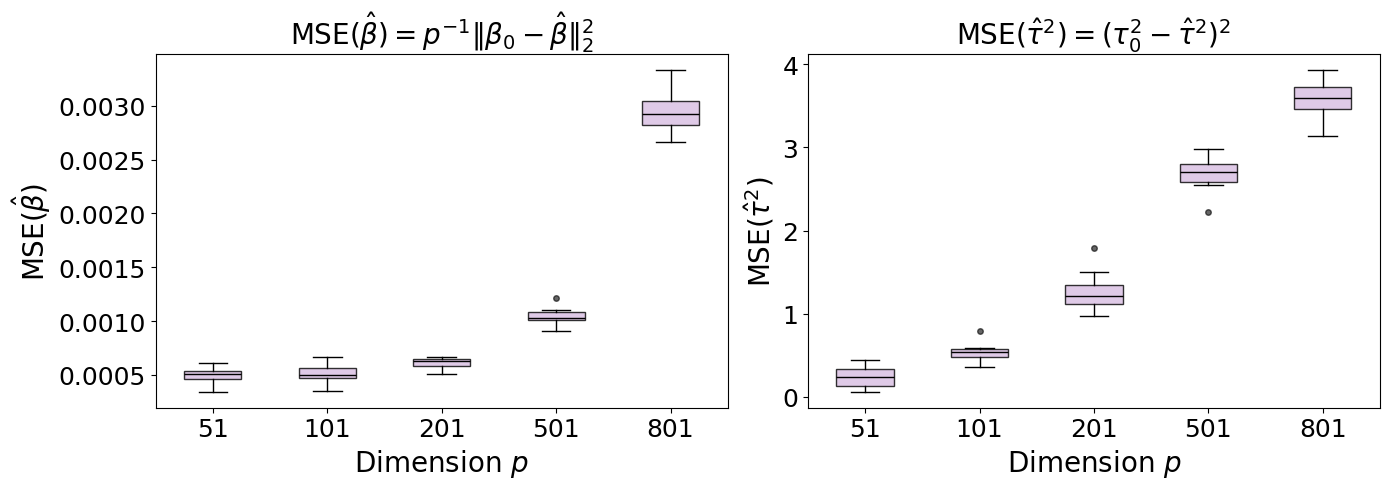

Plot saved to: results_scaling_p/mse_boxplots_scaling_p_student_t.pdf


In [5]:
# ============================================================
# Create output folder
# ============================================================
output_dir = "results_scaling_p"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# Side-by-side boxplots for MSE(beta) and MSE(tau^2)
# ============================================================
box_color = "#D7BDE2"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------
# Left panel: MSE(beta)
# ---------------------------
data_beta = [results_df.loc[results_df["p"] == p, "MSE_beta"].values for p in p_values]

bp1 = axes[0].boxplot(
    data_beta,
    tick_labels=[str(p+1) for p in p_values],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1),
    boxprops=dict(edgecolor="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1),
    capprops=dict(color="black", linewidth=1),
    flierprops=dict(
        marker='o',
        markerfacecolor="black",
        markeredgecolor="black",
        alpha=0.6,
        markersize=4
    )
)

for patch in bp1["boxes"]:
    patch.set_facecolor(box_color)
    patch.set_alpha(0.8)

axes[0].set_xlabel(r"Dimension $p$", fontsize=20)
axes[0].set_ylabel(r"$\mathrm{MSE}(\hat{\beta})$", fontsize=20)
axes[0].set_title(r"$\mathrm{MSE}(\hat{\beta}) = p^{-1}\|\beta_0-\hat{\beta}\|_{2}^{2}$", fontsize=20)

# ---------------------------
# Right panel: MSE(tau^2)
# ---------------------------
data_tau2 = [results_df.loc[results_df["p"] == p, "MSE_tau2"].values for p in p_values]

bp2 = axes[1].boxplot(
    data_tau2,
    tick_labels=[str(p+1) for p in p_values],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1),
    boxprops=dict(edgecolor="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1),
    capprops=dict(color="black", linewidth=1),
    flierprops=dict(
        marker='o',
        markerfacecolor="black",
        markeredgecolor="black",
        alpha=0.6,
        markersize=4
    )
)

for patch in bp2["boxes"]:
    patch.set_facecolor(box_color)
    patch.set_alpha(0.8)

axes[1].set_xlabel(r"Dimension $p$", fontsize=20)
axes[1].set_ylabel(r"$\mathrm{MSE}(\hat{\tau}^2)$", fontsize=20)
axes[1].set_title(r"$\mathrm{MSE}(\hat{\tau}^{2}) = (\tau_0^2 - \hat{\tau}^2)^2$", fontsize=20)
#axes[1].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.tick_params(axis="both", which="both", labelsize=18)

plt.tight_layout()

# ============================================================
# Save figure
# ============================================================
save_path = os.path.join(output_dir, "mse_boxplots_scaling_p_student_t.pdf")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot saved to: {save_path}")

### For Negative-Binomial SSG Type II: Figure 37 in Supplementary Materials

See: `results_scaling_p/mse_boxplots_scaling_p_negbin.pdf`

In [ ]:
# ============================================================
# Settings
# ============================================================
np.random.seed(123)

n = 400
total_p_values = [11, 51, 101, 151, 201] # total_p_values = p_values + 1
p_values = [10, 50, 100, 150, 200]
num_reps = 10
r = 10

# ============================================================
# Storage
# ============================================================
mse_beta_TAVIE = np.zeros((len(p_values), num_reps))
time_TAVIE = np.zeros((len(p_values), num_reps))

records = []

# ============================================================
# Main experiment loop: fixed n, varying p
# ============================================================
for i, p in enumerate(p_values):
    # print(f"Running p = {p} ...")

    for rep in tqdm(range(num_reps), desc=f"p = {p}", leave=True):
        # ----------------------------------------------------
        # Generate true beta for this repetition
        # ----------------------------------------------------
        beta_true = np.random.normal(loc=0.0, scale=0.5, size=p + 1)

        # ----------------------------------------------------
        # Generate data
        # ----------------------------------------------------
        X = np.random.normal(size=(n, p))
        linear_term = beta_true[0] + X @ beta_true[1:]

        # success probability in (0,1)
        probs = 1.0 / (1.0 + np.exp(-linear_term))

        # NumPy parameterization:
        # y ~ NB(r, probs), where probs is the success probability
        y = np.random.negative_binomial(r, probs, size=n)

        # ----------------------------------------------------
        # Initialize a fresh TAVIE model each repetition
        # ----------------------------------------------------
        negbin_tavie_model = TAVIE_type_II(
            family="negbin",
            fit_intercept=True
        )

        # ----------------------------------------------------
        # Fit model and time it
        # ----------------------------------------------------
        t0 = perf_counter()
        # increase maxiter if required
        negbin_tavie_model.fit(X, y, r=r, tol= 1e-5, maxiter = 1e3, verbose=False)
        elapsed = perf_counter() - t0

        # ----------------------------------------------------
        # Extract estimates
        # ----------------------------------------------------
        beta_est_TAVIE = negbin_tavie_model.get_TAVIE_means(verbose=False)

        # ----------------------------------------------------
        # Compute error
        # ----------------------------------------------------
        mse_beta = np.mean((beta_est_TAVIE - beta_true) ** 2)

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------
        time_TAVIE[i, rep] = elapsed
        mse_beta_TAVIE[i, rep] = mse_beta

        records.append({
            "p": p,
            "rep": rep + 1,
            "MSE_beta": mse_beta,
            "time_sec": elapsed
        })

# ============================================================
# Convert to DataFrame
# ============================================================
results_df = pd.DataFrame(records)

print("\nSummary:")
print(results_df.groupby("p")[["MSE_beta", "time_sec"]].agg(["mean", "median", "std"]))

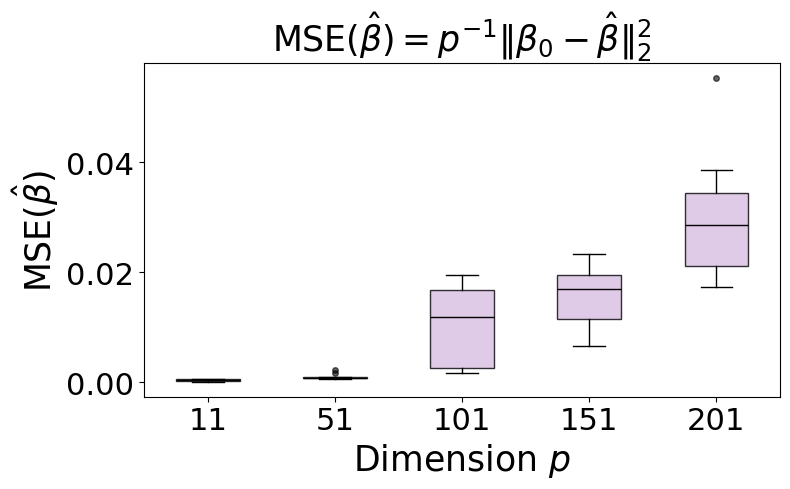

Plot saved to: results_scaling_p/mse_boxplots_scaling_p_negbin.pdf


In [7]:
# ============================================================
# Create output folder
# ============================================================
output_dir = "results_scaling_p"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# Boxplot for MSE(beta)
# ============================================================
box_color = "#D7BDE2"

fig, ax = plt.subplots(figsize=(8, 5))

data_beta = [results_df.loc[results_df["p"] == p, "MSE_beta"].values for p in p_values]

bp = ax.boxplot(
    data_beta,
    tick_labels=[str(p+1) for p in p_values],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1),
    boxprops=dict(edgecolor="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1),
    capprops=dict(color="black", linewidth=1),
    flierprops=dict(
        marker='o',
        markerfacecolor="black",
        markeredgecolor="black",
        alpha=0.6,
        markersize=4
    )
)

for patch in bp["boxes"]:
    patch.set_facecolor(box_color)
    patch.set_alpha(0.8)

ax.set_xlabel(r"Dimension $p$", fontsize=25)
ax.set_ylabel(r"$\mathrm{MSE}(\hat{\beta})$", fontsize=25)
ax.set_title(r"$\mathrm{MSE}(\hat{\beta}) = p^{-1}\|\beta_0-\hat{\beta}\|_2^2$", fontsize=25)
ax.tick_params(axis="both", which="both", labelsize=22)
    
plt.tight_layout()

# ============================================================
# Save figure
# ============================================================
save_path = os.path.join(output_dir, "mse_boxplots_scaling_p_negbin.pdf")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot saved to: {save_path}")